In [5]:
using Plots
using ColorSchemes

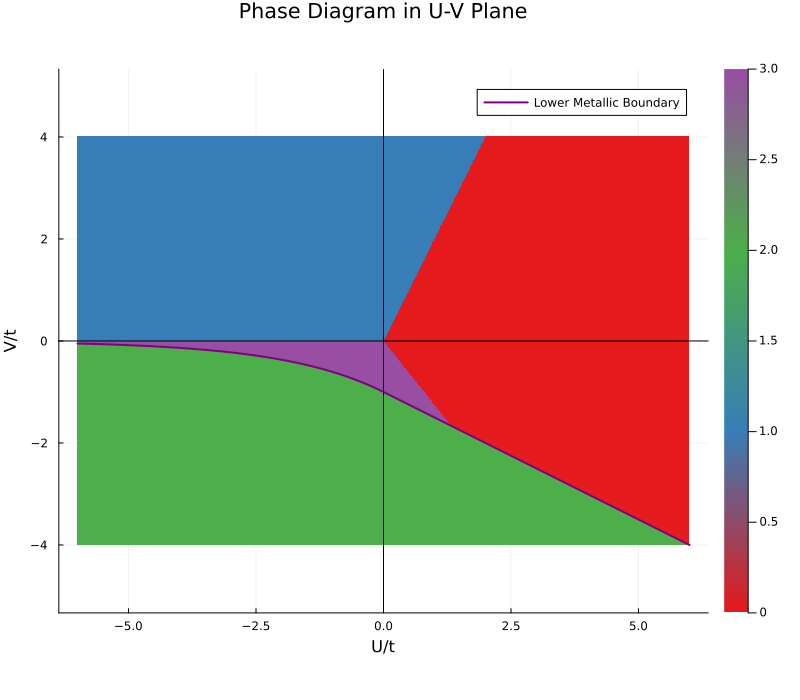

In [10]:
U_0 = -6.0
U_f = 6.0
V_0 = -4.0
V_f = 4.0
N_points = 1000

u_vals = range(U_0, U_f, length=N_points)
v_vals = range(V_0, V_f, length=N_points)
U_grid = [u for v in v_vals, u in u_vals]
V_grid = [v for v in v_vals, u in u_vals]

# Phase map and color palette
phase_map_dict = Dict(
    "SDW" => 0,
    "CDW" => 1,
    "PS" => 2,
    "METALLIC" => 3
)

defined_colors = [:blue, :green, :red, :yellow]

alpha = 0.5
# Boundary functions
get_metallic_lower_boundary(u) = u <= 0 ? -exp(alpha * u) : -alpha * u - 1.0
get_metallic_upper_boundary_h(u) = -0.1 * u
get_metallic_upper_boundary_negative(u) = -2.5 * alpha * u

# Initialize phase array
color_indices = fill(0, N_points, N_points)

# Main loop over grid
for i in 1:N_points, j in 1:N_points
    u = U_grid[i, j]
    v = V_grid[i, j]

    lower = get_metallic_lower_boundary(u)
    upper_h = get_metallic_upper_boundary_h(u)
    upper_neg = get_metallic_upper_boundary_negative(u)

    if v <= lower
        color_indices[i, j] = phase_map_dict["PS"]
    elseif (u < 0 && v < 0 && v > lower) ||
           (u > 0 && v > 0 && v < upper_h) ||
           (u > 0 && v < 0 && v > lower && v < upper_neg)
        color_indices[i, j] = phase_map_dict["METALLIC"]
    elseif (u < 0 && v > 0) ||
           (u > 0 && v > 0 && v >= 2 * u)
        color_indices[i, j] = phase_map_dict["CDW"]
    elseif (u > 0 && v < 0 && v > lower) ||
           (u > 0 && v > 0 && v >= upper_h && v < 2 * u)
        color_indices[i, j] = phase_map_dict["SDW"]
    else
        color_indices[i, j] = phase_map_dict["PS"]
    end
end

# Plotting
plot(
    title="Phase Diagram in U-V Plane",
    xlabel="U/t", ylabel="V/t",
    size=(800, 700), aspect_ratio=:equal,
    legend=:topright
)

# Use heatmap for phase display
heatmap!(
    u_vals, v_vals, color_indices;
    c=:Set1_4,
    clims=(0, 3),
    colorbar_ticks=(0:3, ["SDW", "CDW", "PS", "METALLIC"]),
    interpolate=false
)

# Add lower boundary line
line_u_lower = range(U_0, U_f, length=2 * N_points)
line_v_lower = [get_metallic_lower_boundary(u) for u in line_u_lower]
plot!(line_u_lower, line_v_lower, color=:purple, lw=2, label="Lower Metallic Boundary")

# Draw horizontal and vertical axes
vline!([0.0], lw=1, color=:black, label=false)
hline!([0.0], lw=1, color=:black, label=false)